# Captura y Análisis de Señales Bluetooth Low Energy (BTLE)

Este notebook se conecta a un Ettus USRP B200 para capturar una ráfaga de señal en la frecuencia de un canal de advertising de BTLE, y posteriormente grafica su respuesta en el tiempo y en frecuencia.

In [1]:
import uhd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURACIONES DEL SDR
# ==========================================
center_freq = 2402e6  # 2402 MHz (Canal 0)
sample_rate = 20e6    # 20 Msps (Para ver +-10 MHz y calcular ACP)\n
gain = 40             # Ganancia RX
capture_duration = 0.05 # 50 milisegundos

# 1. Inicializar USRP B200
usrp = uhd.usrp.MultiUSRP("type=b200")
usrp.set_rx_rate(sample_rate, 0)
usrp.set_rx_freq(uhd.libpyuhd.types.tune_request(center_freq), 0)
usrp.set_rx_gain(gain, 0)
usrp.set_rx_antenna("RX2", 0)

# 2. Configurar Streamer para recepción
st_args = uhd.usrp.StreamArgs("fc32", "sc16")
st_args.channels = [0]
rx_streamer = usrp.get_rx_stream(st_args)

# 3. Capturar Muestras
num_samps = int(sample_rate * capture_duration)
recv_buffer = np.zeros((1, num_samps), dtype=np.complex64)
metadata = uhd.types.RXMetadata()

# Iniciar recepción de forma continua
stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)
stream_cmd.stream_now = True
rx_streamer.issue_stream_cmd(stream_cmd)

samples_received = 0
while samples_received < num_samps:
    temp_buff = np.zeros((1, rx_streamer.get_max_num_samps()), dtype=np.complex64)
    n = rx_streamer.recv(temp_buff, metadata)
    if n > 0:
        end_idx = min(samples_received + n, num_samps)
        n_copy = end_idx - samples_received
        recv_buffer[0, samples_received:end_idx] = temp_buff[0, :n_copy]
        samples_received += n_copy

# Detener el flujo
stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont)
rx_streamer.issue_stream_cmd(stream_cmd)

iq_samples = recv_buffer[0]
print(f"Captura finalizada: {len(iq_samples)} muestras obtenidas.")


/home/alanastasio/repos/auto/demodulador/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Captura finalizada: 1000000 muestras obtenidas.


[INFO] [UHD] linux; GNU C++ version 13.2.0; Boost_108300; UHD_4.6.0.0+ds1-5.1ubuntu0.24.04.1
[INFO] [B200] Detected Device: B200
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 20.000000 MHz... 
[INFO] [B200] Actually got clock rate 20.000000 MHz.


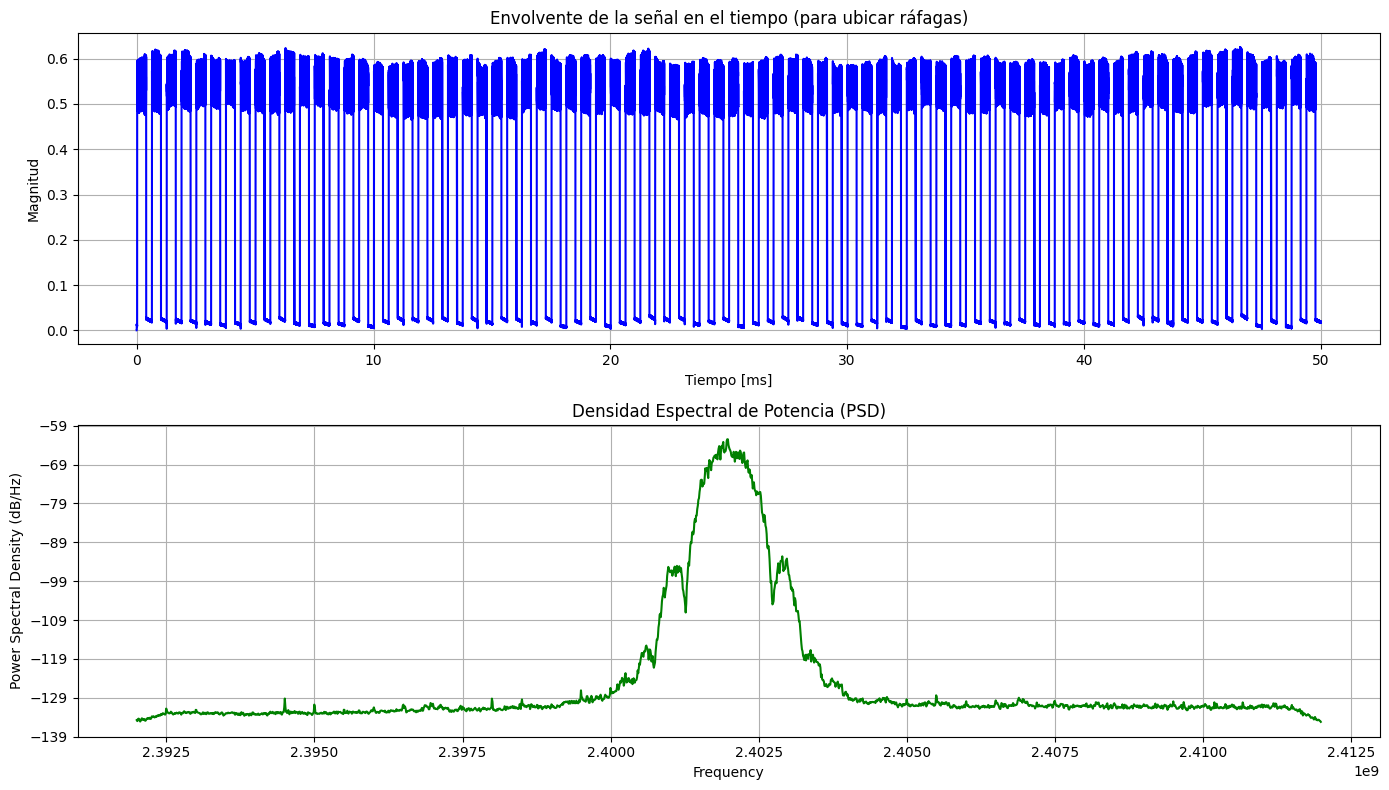

In [2]:
# ==========================================
# VISUALIZACIÓN EN TIEMPO Y FRECUENCIA
# ==========================================
time_axis = np.arange(len(iq_samples)) / sample_rate * 1000  # ms

plt.figure(figsize=(14, 8))

# Graficar envolvente en el tiempo
plt.subplot(2, 1, 1)
plt.plot(time_axis, np.abs(iq_samples), color='blue')
plt.title('Envolvente de la señal en el tiempo (para ubicar ráfagas)')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Magnitud')
plt.grid(True)

# Graficar el espectro (PSD)
plt.subplot(2, 1, 2)
plt.psd(iq_samples, NFFT=2048, Fs=sample_rate, Fc=center_freq, color='green')
plt.title('Densidad Espectral de Potencia (PSD)')

plt.tight_layout()
plt.show()


¡Se encontraron 80 ráfagas válidas!
Primera ráfaga inicia en la muestra 316, duración real: 383.8 us.


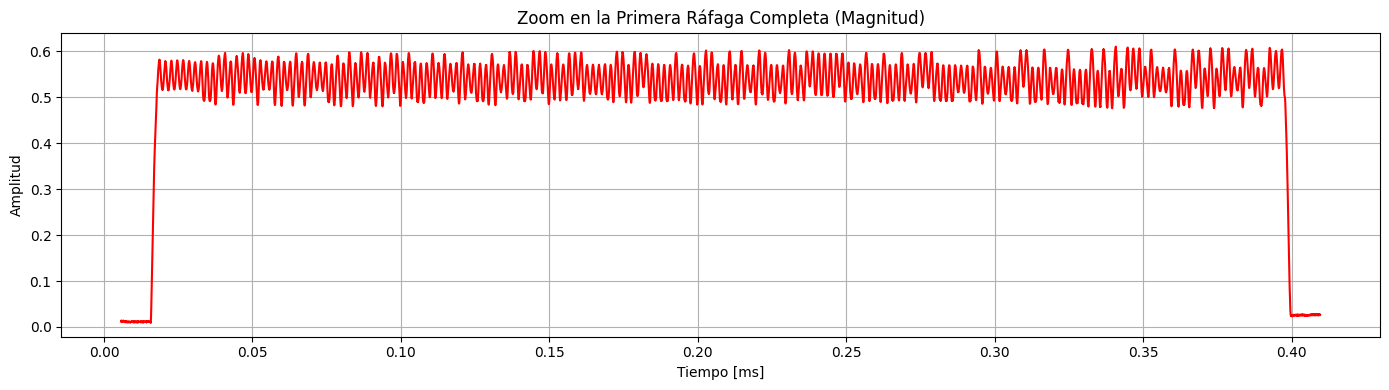

In [3]:
# ==========================================
# DETECCIÓN DE RÁFAGAS (BURST DETECTION)
# ==========================================
import scipy.signal as signal

# 1. Calcular la potencia instantánea de la señal
power = np.abs(iq_samples)**2

# 2. Filtro de media móvil (ventana de 5 us)
window_size = int(sample_rate * 5e-6)
window = np.ones(window_size) / window_size
smoothed_power = np.convolve(power, window, mode='same')

# 3. Definir un umbral basado en el rango dinámico de la señal
p_min = np.min(smoothed_power)
p_max = np.max(smoothed_power)
threshold = p_min + (p_max - p_min) * 0.2  # Umbral al 20% del pico máximo

# 4. Encontrar transiciones
is_active = smoothed_power > threshold
edges = np.diff(is_active.astype(int))
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0]

if is_active[0]: starts = np.insert(starts, 0, 0)
if is_active[-1]: ends = np.append(ends, len(iq_samples)-1)

# 5. Filtrar ráfagas
min_len = int(sample_rate * 20e-6)   # Mínimo 20 us
valid_bursts = []
for s, e in zip(starts, ends):
    if (e - s) > min_len:
        if s > 0 and e < len(iq_samples) - 1:
            valid_bursts.append((s, e))

if len(valid_bursts) > 0:
    first_burst_start, first_burst_end = valid_bursts[0]
    margin = int(sample_rate * 10e-6) # 10 us de margen
    extract_start = max(0, first_burst_start - margin)
    extract_end = min(len(iq_samples), first_burst_end + margin)
    
    burst_samples = iq_samples[extract_start:extract_end]
    burst_time = time_axis[extract_start:extract_end]
    
    dur_us = (first_burst_end - first_burst_start) / sample_rate * 1e6
    print(f"¡Se encontraron {len(valid_bursts)} ráfagas válidas!")
    print(f"Primera ráfaga inicia en la muestra {first_burst_start}, duración real: {dur_us:.1f} us.")
    
    plt.figure(figsize=(14, 4))
    plt.plot(burst_time, np.abs(burst_samples), color='red')
    plt.title('Zoom en la Primera Ráfaga Completa (Magnitud)')
    plt.xlabel('Tiempo [ms]')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron ráfagas válidas completas. Mostrando potencia y umbral para depurar:")
    plt.figure(figsize=(14, 4))
    plt.plot(time_axis, smoothed_power, label='Potencia Suavizada')
    plt.axhline(threshold, color='red', linestyle='--', label='Umbral (20%)')
    plt.legend()
    plt.show()
    burst_samples = None


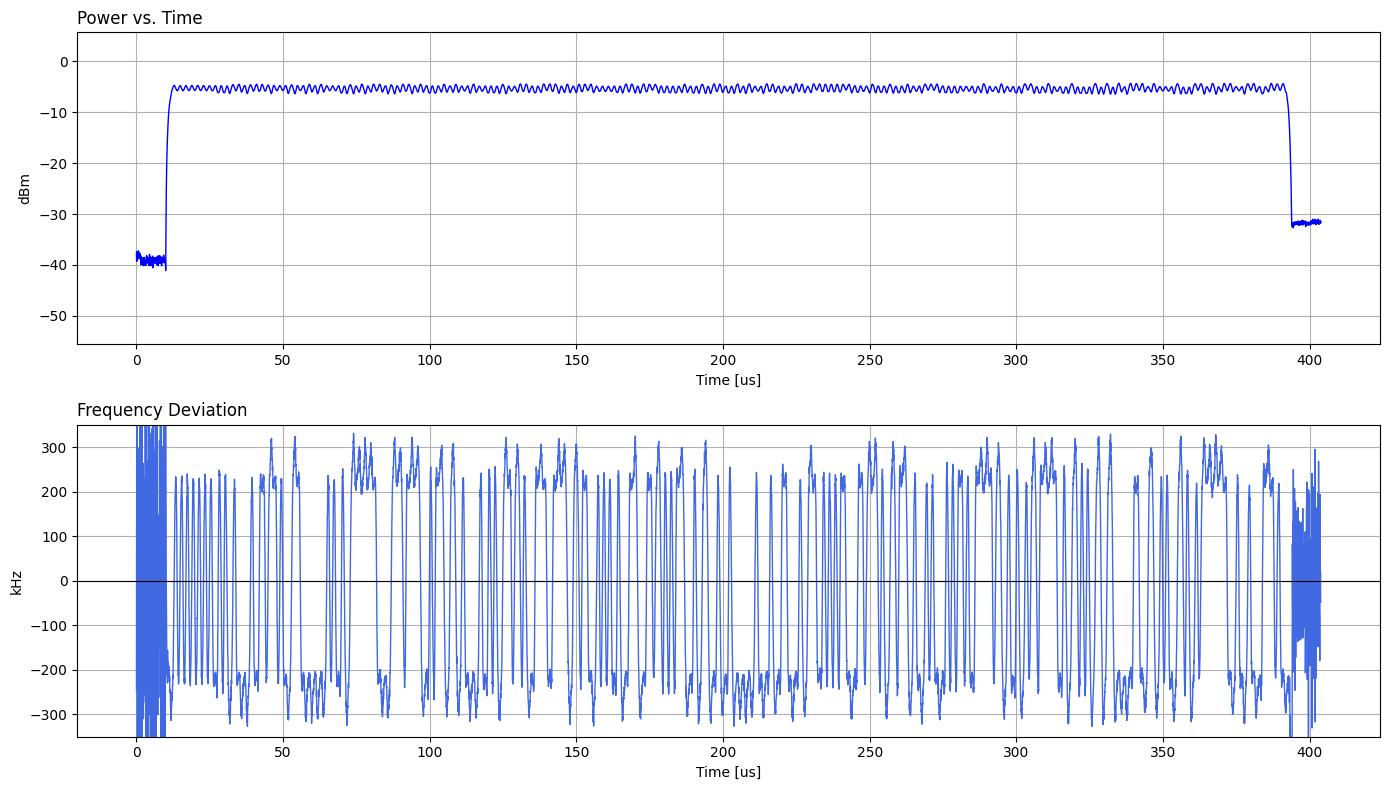

----------------------------------------------------------------------
TX Measurement Modulation
----------------------------------------------------------------------
Nominal Power [dBm]:  -5.57   |   Freq Accuracy [kHz]:  -0.61

----------------------------------------------------------------------
TX Measurement Power vs. Time
----------------------------------------------------------------------
Average Power [dBm]:  -5.57   |   Peak Power [dBm]:  -4.29   |   Peak - Avg [dB]:   1.28
----------------------------------------------------------------------


In [4]:
# ==========================================
# ANÁLISIS TIPO CMW500 (Demodulación y Potencia)
# ==========================================

# 1. Power vs Time (dBm relativo)
# Asumimos que amplitud 1.0 = 0 dBm
power_mw = np.abs(burst_samples)**2
power_dbm = 10 * np.log10(power_mw + 1e-12)

# Métricas de Potencia
avg_power_dbm = 10 * np.log10(np.mean(power_mw))
peak_power_dbm = np.max(power_dbm)
peak_to_avg_db = peak_power_dbm - avg_power_dbm
nominal_power_dbm = avg_power_dbm

# 2. Desviación de Frecuencia (FM Demodulation)
# Derivada de la fase para obtener la frecuencia instantánea
phase = np.unwrap(np.angle(burst_samples))
freq_dev_hz = np.diff(phase) / (2 * np.pi) * sample_rate
freq_dev_hz = np.append(freq_dev_hz, freq_dev_hz[-1])

# Frecuencia central (Freq Accuracy / Offset)
preamble_len = int(sample_rate * 8e-6)
freq_accuracy_khz = np.mean(freq_dev_hz[:preamble_len]) / 1000.0

freq_dev_khz = freq_dev_hz / 1000.0

# --- 3. GRÁFICOS Y TABLAS ---
burst_time_us = np.arange(len(burst_samples)) / sample_rate * 1e6

fig = plt.figure(figsize=(14, 8))

# GRÁFICO 1: Power vs Time
ax1 = plt.subplot(2, 1, 1)
ax1.plot(burst_time_us, power_dbm, color='blue', linewidth=1)
ax1.set_title('Power vs. Time', loc='left')
ax1.set_ylabel('dBm')
ax1.set_xlabel('Time [us]')
ax1.grid(True)
ax1.set_ylim(avg_power_dbm - 50, peak_power_dbm + 10)

# GRÁFICO 2: Frequency Deviation
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(burst_time_us, freq_dev_khz, color='royalblue', linewidth=1)
ax2.set_title('Frequency Deviation', loc='left')
ax2.set_ylabel('kHz')
ax2.set_xlabel('Time [us]')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True)
ax2.set_ylim(-350, 350)

plt.tight_layout()
plt.show()

# TABLAS ESTILO CMW500
print("-" * 70)
print("TX Measurement Modulation")
print("-" * 70)
print(f"Nominal Power [dBm]: {nominal_power_dbm:6.2f}   |   Freq Accuracy [kHz]: {freq_accuracy_khz:6.2f}")
print("\n" + "-" * 70)
print("TX Measurement Power vs. Time")
print("-" * 70)
print(f"Average Power [dBm]: {avg_power_dbm:6.2f}   |   Peak Power [dBm]: {peak_power_dbm:6.2f}   |   Peak - Avg [dB]: {peak_to_avg_db:6.2f}")
print("-" * 70)


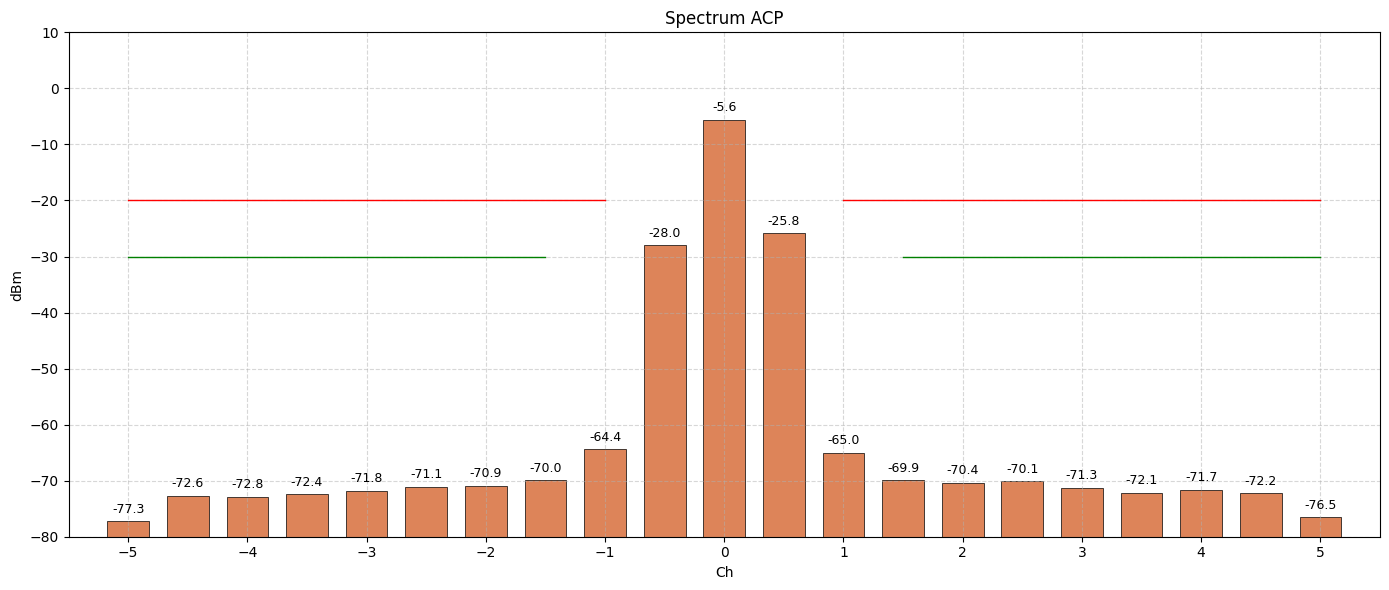

[ERROR] [UHD] An unexpected exception was caught in a task loop.The task loop will now exit, things may not work.EnvironmentError: IOError: usb rx8 transfer status: LIBUSB_TRANSFER_NO_DEVICE


In [5]:
# ==========================================
# SPECTRUM ACP (Adjacent Channel Power) - CMW500 Clone
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

N = len(burst_samples)
fft_vals = np.fft.fftshift(np.fft.fft(burst_samples)) / N
power_spectrum = np.abs(fft_vals)**2
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/sample_rate))

# El ancho de banda de medición para ACP en BTLE es de 1 MHz
channel_bandwidth = 1e6

# El CMW500 grafica de -5 a +5 Canales.
# Como 1 Canal BTLE = 2 MHz, esto equivale a offsets de -10 MHz a +10 MHz.
offsets_mhz = np.arange(-10, 11)
channel_offsets_ch = offsets_mhz / 2.0  # Eje X en "Canales"

channel_power_dbm = []

for offset_mhz in offsets_mhz:
    center_f = offset_mhz * 1e6
    idx = np.where((freqs >= center_f - channel_bandwidth/2) & (freqs <= center_f + channel_bandwidth/2))[0]
    if len(idx) > 0:
        pwr_mw = np.sum(power_spectrum[idx])
        pwr_dbm = 10 * np.log10(pwr_mw + 1e-12)
    else:
        pwr_dbm = -100
    channel_power_dbm.append(pwr_dbm)

plt.figure(figsize=(14, 6))

# Graficamos las barras
floor = -80
heights = np.maximum(np.array(channel_power_dbm), floor) - floor
bars = plt.bar(channel_offsets_ch, heights, bottom=floor, width=0.35, color='#dd8459', edgecolor='black', linewidth=0.5)

plt.title('Spectrum ACP')
plt.xlabel('Ch')
plt.ylabel('dBm')

# Configurar el eje X para que los ticks sean los números enteros de canal
plt.xticks(np.arange(-5, 6))
# Configurar el eje Y para divisiones de 10 en 10
plt.yticks(np.arange(-80, 20, 10))

plt.grid(True, axis='both', linestyle='--', alpha=0.5)

# Agregar etiquetas de valor a las barras de nuevo
for i, bar in enumerate(bars):
    true_val = channel_power_dbm[i]
    if true_val > -78:  # Solo etiquetar si no es puro ruido nulo
        y_pos = max(true_val, floor) + 1
        plt.text(bar.get_x() + bar.get_width()/2, y_pos, f'{true_val:.1f}', ha='center', va='bottom', fontsize=9)


# Agregar líneas de límite de la norma Bluetooth SIG (igual al CMW500)
# Línea roja (-20 dBm) para offset >= 2 MHz (1 Ch)
plt.plot([-5, -1], [-20, -20], color='red', linewidth=1)
plt.plot([1, 5], [-20, -20], color='red', linewidth=1)

# Línea verde (-30 dBm) para offset >= 3 MHz (1.5 Ch)
plt.plot([-5, -1.5], [-30, -30], color='green', linewidth=1)
plt.plot([1.5, 5], [-30, -30], color='green', linewidth=1)

plt.ylim(-80, 10)
plt.xlim(-5.5, 5.5)

plt.tight_layout()
plt.show()
